In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

df = pd.read_csv('heart.csv', header=None)

df.columns = [
    "вік", "стать", "тип_болю", "тиск", "холестерин", "цукор", "екг", 
    "макс_пульс", "стенокардія", "депресія_st", "нахил_st", "судини", "thal", "діагноз"
]

print("Дані успішно завантажено!")
print(f"Розмір таблиці: {df.shape}")
df.head()

Дані успішно завантажено!
Розмір таблиці: (303, 14)


,вік,стать,тип_болю,тиск,холестерин,цукор,екг,макс_пульс,стенокардія,депресія_st,нахил_st,судини,thal,діагноз
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [11]:
df = df.replace('?', np.nan)

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

object_cols = df.select_dtypes(include=['object']).columns
for col in object_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Очищення завершено успішно!")
print(f"Загальна кількість пропусків після обробки: {df.isnull().sum().sum()}")

Очищення завершено успішно!
Загальна кількість пропусків після обробки: 0


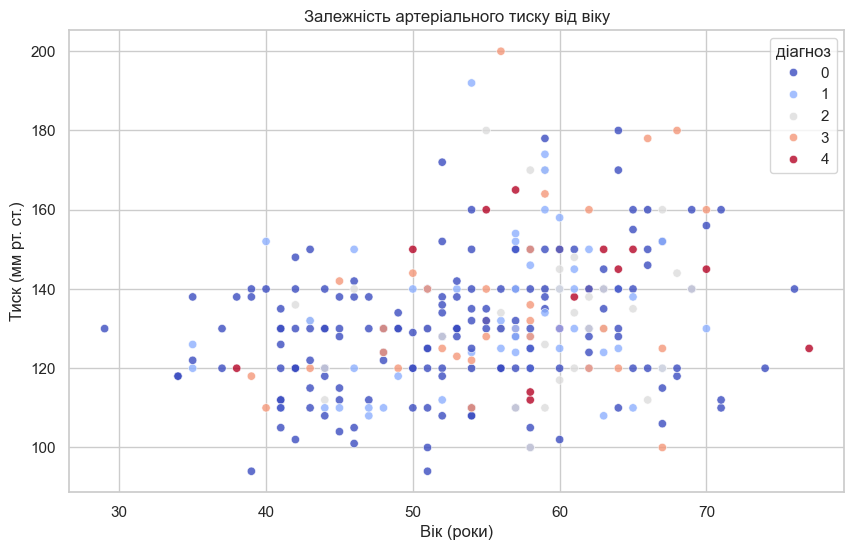

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='вік', y='тиск', hue='діагноз', palette='coolwarm', alpha=0.8)
plt.title('Залежність артеріального тиску від віку')
plt.xlabel('Вік (роки)')
plt.ylabel('Тиск (мм рт. ст.)')
plt.show()

Візуалізація: Побудовано графік залежності ознаки тиск від ознаки вік.

Розподіл: Більшість пацієнтів зосереджена в діапазоні від 40 до 70 років із тиском 120–140 мм.

Висновки: Чіткої лінійної залежності не виявлено, проте аномально високі показники тиску (понад 160 мм) частіше притаманні людям старше 50 років.

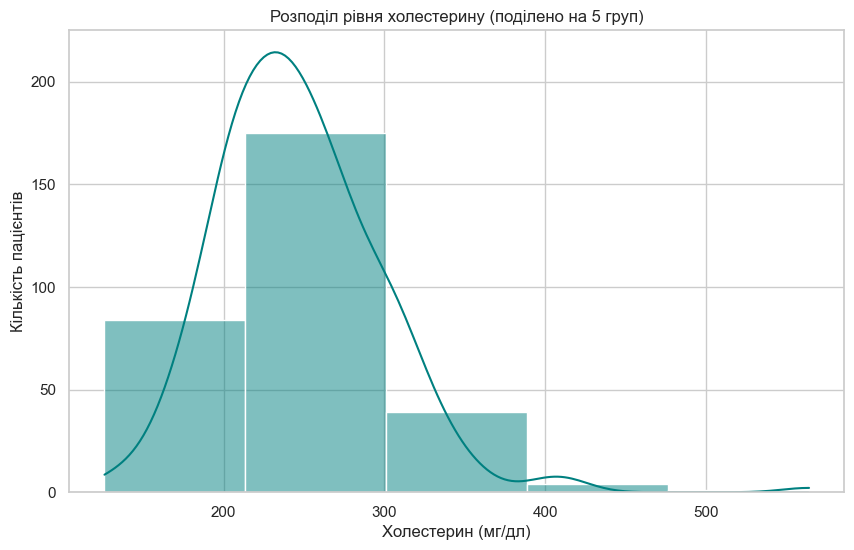

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(df['холестерин'], bins=5, color='teal', kde=True)
plt.title('Розподіл рівня холестерину (поділено на 5 груп)')
plt.xlabel('Холестерин (мг/дл)')
plt.ylabel('Кількість пацієнтів')
plt.show()

Домінуюча група: Найбільша кількість пацієнтів (понад 150 осіб) мають рівень холестерину в другому діапазоні (приблизно 220–300 мг/дл).

Аномалії: На графіку помітно довгий хвіст праворуч - це поодинокі випадки з дуже високим рівнем холестерину (понад 400 мг/дл), які можна вважати викидами.

Висновки: Поділ на 5 кошиків дозволяє чітко побачити, що дані не є рівномірними, а мають яскраво виражений центр.

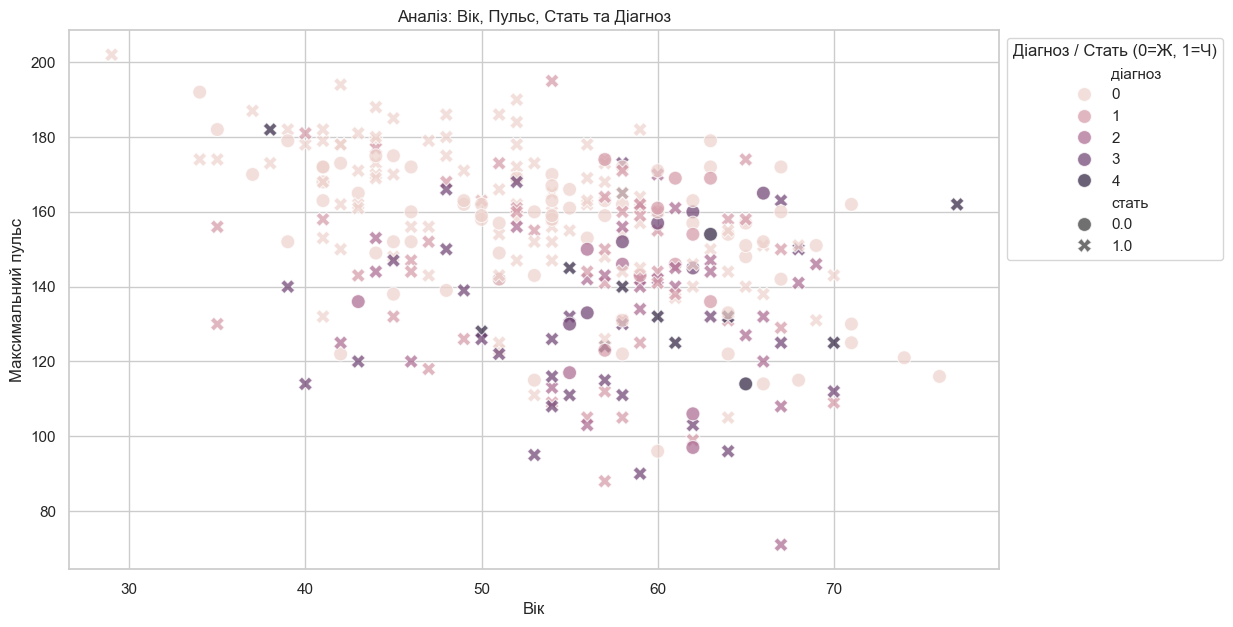

In [14]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df, 
    x='вік', 
    y='макс_пульс', 
    hue='діагноз', 
    style='стать', 
    s=100, 
    alpha=0.7
)
plt.title('Аналіз: Вік, Пульс, Стать та Діагноз')
plt.xlabel('Вік')
plt.ylabel('Максимальний пульс')
plt.legend(title='Діагноз / Стать (0=Ж, 1=Ч)', bbox_to_anchor=(1, 1))
plt.show()

Вік та Пульс: Спостерігається чітка зворотна залежність - із віком максимальний пульс пацієнтів закономірно знижується.

Стать: Використання різних маркерів дозволяє побачити розподіл між чоловіками та жінками у вибірці.

Діагноз: Темніші відтінки відповідають важчим ступеням захворювання. Можна помітити, що пацієнти з вищим рівнем діагнозу часто мають нижчий показник максимального пульсу для своєї вікової категорії.

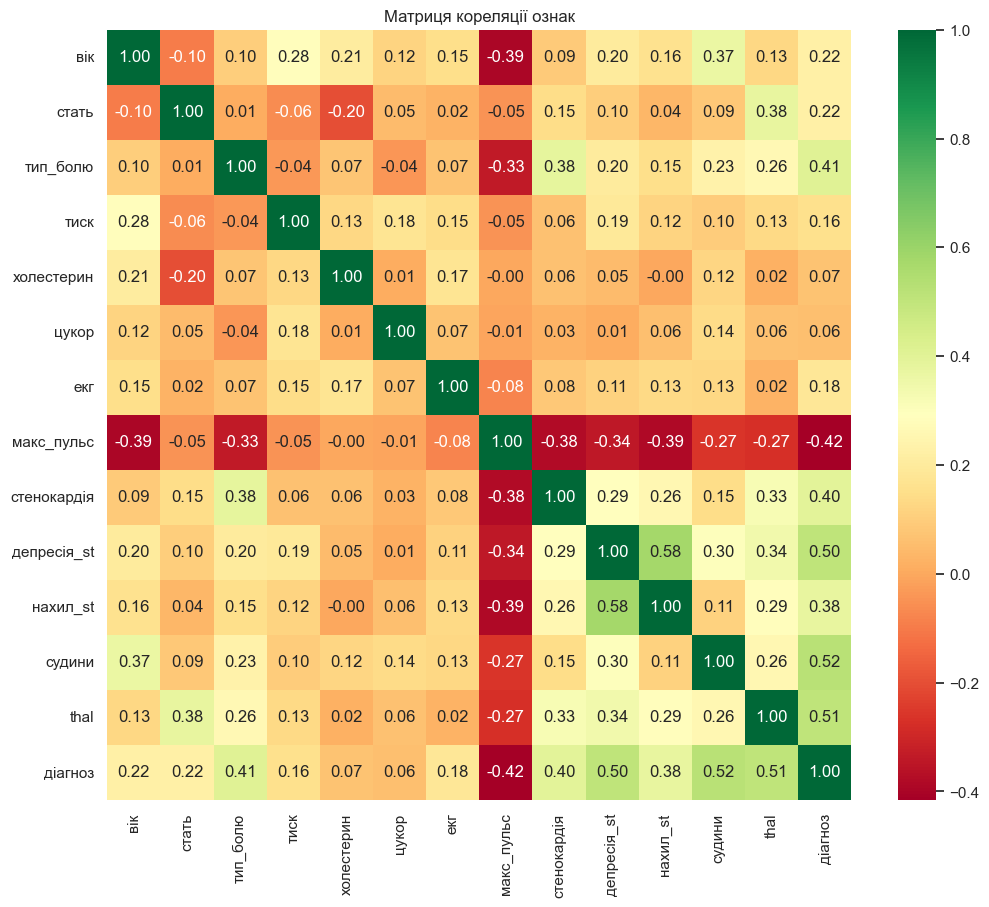

In [15]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Матриця кореляції ознак')
plt.show()

Найсильніші предиктори діагнозу: Показник діагноз найбільше корелює з кількістю зафарбованих судин (судини, 0.52), показником thal (0.51) та депресією сегмента ST (депресія_st, 0.50). Це ключові фактори для визначення хвороби.

Зворотні зв'язки: Спостерігається помітна від'ємна кореляція між діагнозом та максимальним пульсом (макс_пульс, -0.42). Це підтверджує, що у пацієнтів із патологіями серця максимальна частота скорочень зазвичай нижча.

Фізіологічні закономірності: Очікувано висока кореляція між параметрами ЕКГ (депресія_st та нахил_st, 0.58) свідчить про їхню спільну діагностичну природу.

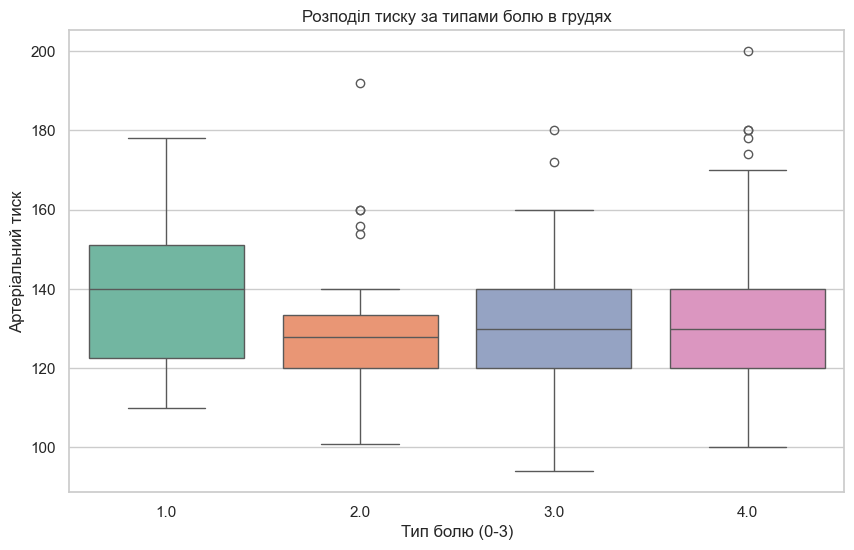

In [17]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='тип_болю', y='тиск', hue='тип_болю', palette='Set2', legend=False)
plt.title('Розподіл тиску за типами болю в грудях')
plt.xlabel('Тип болю (0-3)')
plt.ylabel('Артеріальний тиск')
plt.show()

Центральна тенденція: Медіанний тиск у групі 1.0 є дещо вищим, ніж в інших групах.

Варіативність: Група 1.0 також має найбільший міжквартильний розмах, що свідчить про велику різноманітність показників у цій категорії.

Викиди: Точки над вусами (особливо в групах 2.0, 3.0 та 4.0) вказують на наявність пацієнтів із критично високим тиском (понад 180–200 мм), що значно вибиваються із загальної маси.

Висновок: Хоча середні значення тиску в групах 2.0–4.0 схожі, саме група 4.0 має найбільшу кількість екстремальних значень.